# Networkx

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

# 1) Tracé d'un graphe

networkx permet le tracé d'un graphe simplement à partir de la liste des arêtes entre deux nœuds.
Il s'arrange pour placer au mieux ces nœuds pour faciliter la lisibilité du graphe.

In [4]:
G = nx.Graph()
G.add_edges_from([("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"), ("C", "E")])


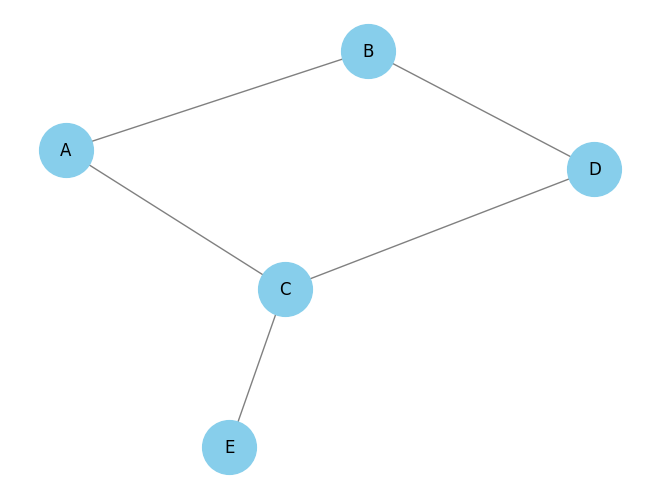

In [3]:
nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray', node_size=1500)


On peut stocker les relations entre les nœuds dans une matrice d'adjacence (symétrique) que l'on va tirer aléatoirement.

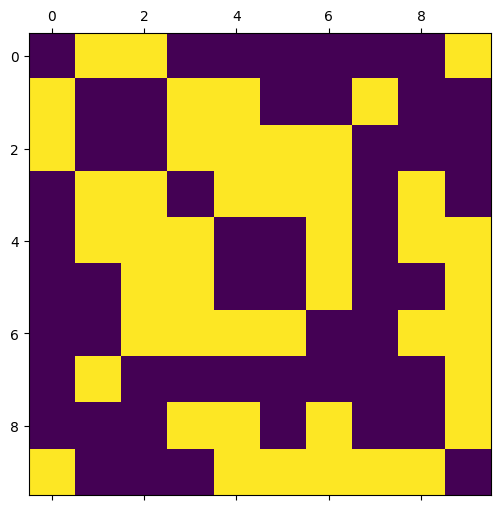

In [6]:
size = 10
adj_matrix = np.random.randint(0, 2, size=(size, size))

adj_matrix = np.triu(adj_matrix, 1)  # Mettre des zéros dans la partie inférieure
adj_matrix = adj_matrix + adj_matrix.T  # Symétriser

fig, ax = plt.subplots(figsize=(8, 6))
ax.matshow(adj_matrix)



En violet on a les nœuds sans lien et en jaune les nœuds à relier.

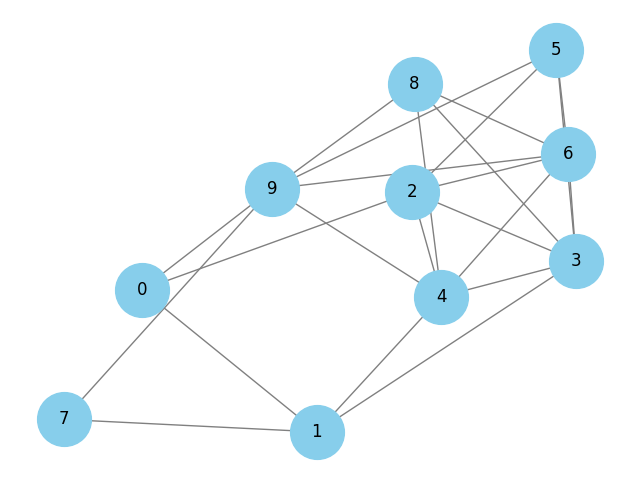

In [7]:

G = nx.from_numpy_array(adj_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='skyblue', edge_color='gray', node_size=1500)



# 2) Caractérisation du graphe

En théorie des graphes, certaines mesures permettent de caractériser la structure du graphe, par exemple :
- Degrés : nombre de liens par nœud
- Centralité (degrés) :  nombre de liens / nombre d'autres nœuds

In [8]:
G = nx.Graph()
G.add_edges_from([("A", "B"), ("A", "C"), ("B", "D"), ("C", "D"), ("C", "E")])

print("Degrés:", dict(G.degree())) # nombre d'échange d'un nœud avec les autres
print("Centralité (degré):", nx.degree_centrality(G))

Degrés: {'A': 2, 'B': 2, 'C': 3, 'D': 2, 'E': 1}
Centralité (degré): {'A': 0.5, 'B': 0.5, 'C': 0.75, 'D': 0.5, 'E': 0.25}


# 3) karate club example

Dans cet exemple les nœuds sont des membres de clubs de karaté qui sont reliés lorsqu'ils se sont affrontés.

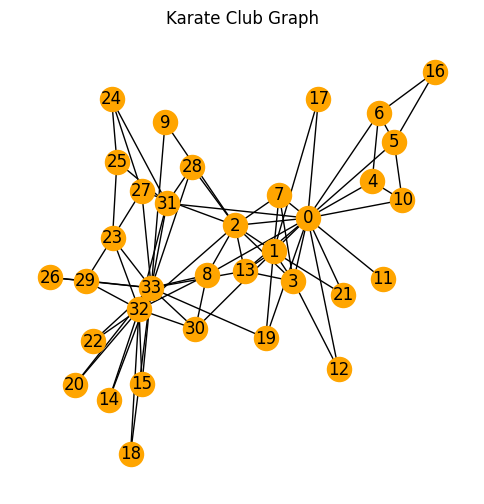

In [10]:
karate = nx.karate_club_graph()
fig, ax = plt.subplots(figsize=(6, 6))
nx.draw(karate, with_labels=True, node_color='orange')
ax.set_title("Karate Club Graph");


In [11]:
communities = nx.algorithms.community.greedy_modularity_communities(karate)
print("Nombre de communautés:", len(communities))

Nombre de communautés: 3


Text(0.5, 1.0, 'Communautés détectées')

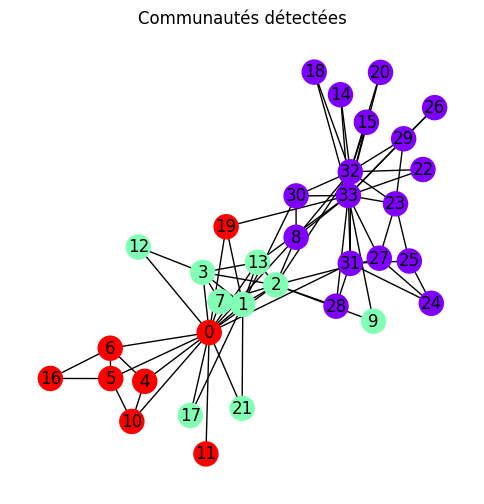

In [12]:
color_map = [0] * karate.number_of_nodes()
for i, comm in enumerate(communities):
    for node in comm:
        color_map[node] = i

fig, ax = plt.subplots(figsize=(6, 6))
nx.draw(karate, node_color=color_map, with_labels=True, cmap=plt.cm.rainbow)
ax.set_title("Communautés détectées")


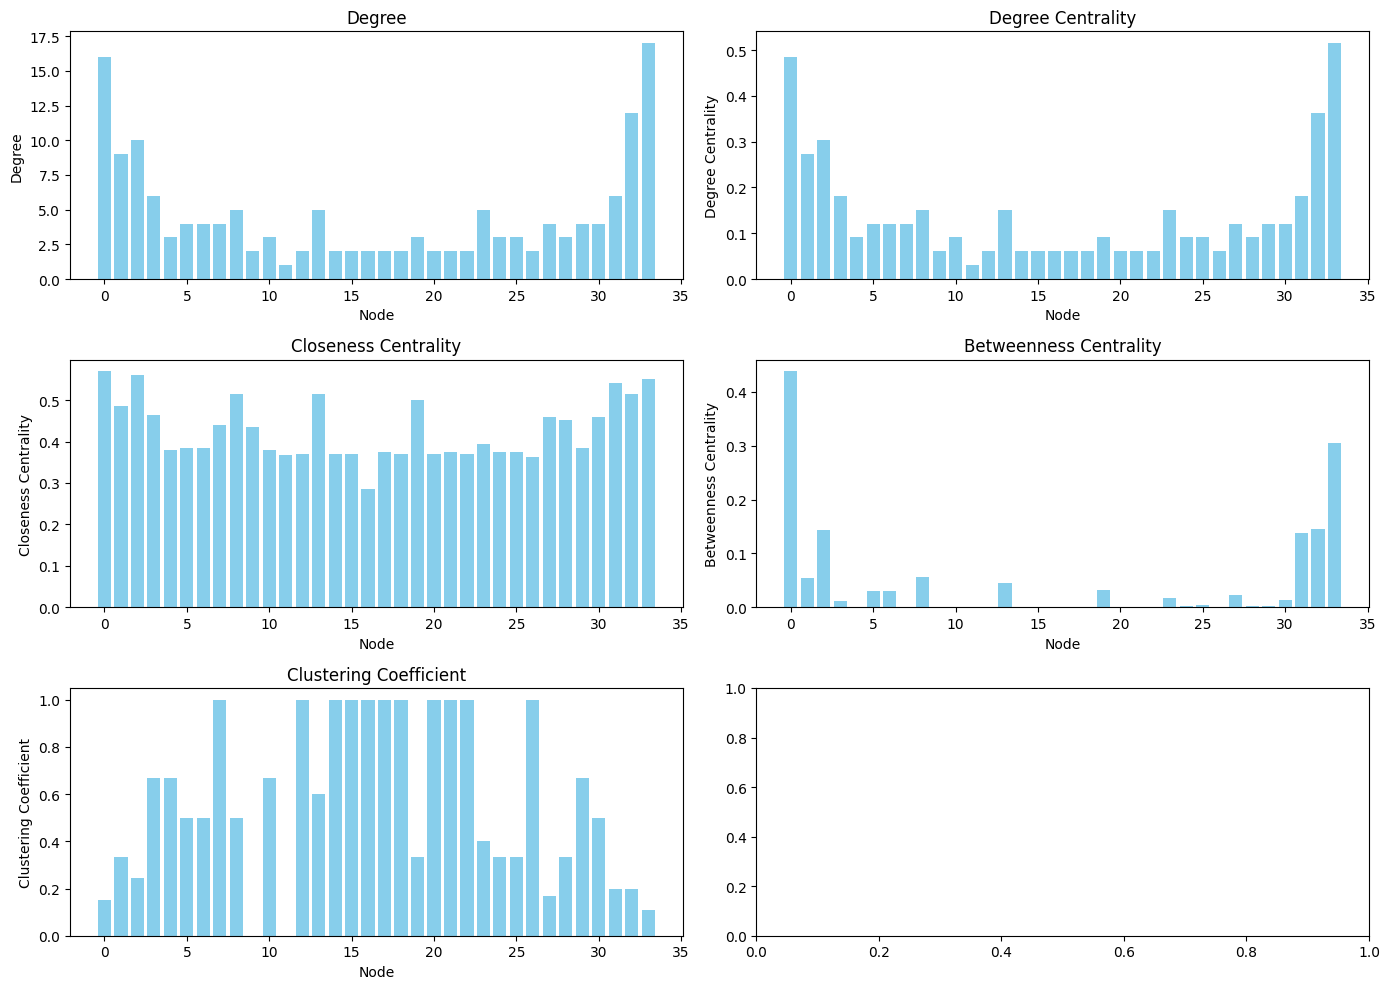

In [13]:

# Calcul des métriques
degree = dict(karate.degree())
degree_centrality = nx.degree_centrality(karate)
closeness_centrality = nx.closeness_centrality(karate)
betweenness_centrality = nx.betweenness_centrality(karate)
clustering = nx.clustering(karate)

# Affichage des métriques pour tous les noeuds
metrics = {
    'Degree': degree,
    'Degree Centrality': degree_centrality,
    'Closeness Centrality': closeness_centrality,
    'Betweenness Centrality': betweenness_centrality,
    'Clustering Coefficient': clustering
}

# Tracer les métriques
fig, axs = plt.subplots(3, 2, figsize=(14, 10))

# Mettre les données sous forme de liste de valeurs triées
sorted_metrics = {metric: sorted(values.items(), key=lambda x: x[1], reverse=True) for metric, values in metrics.items()}

# Tracer chaque métrique
for i, (metric, values) in enumerate(sorted_metrics.items()):
    ax = axs[i // 2, i % 2]
    nodes, values = zip(*values)
    ax.bar(nodes, values, color='skyblue')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel("Node")

fig.tight_layout()

# 4) small world VS random

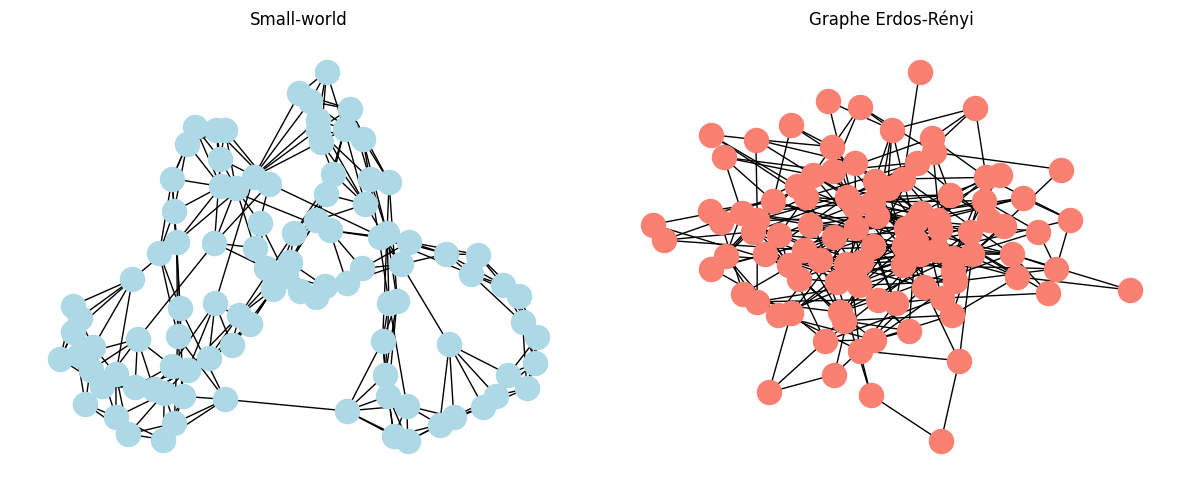

In [15]:
# Création des graphes
n = 100
k = 6
p = 0.05

small_world = nx.watts_strogatz_graph(n=n, k=k, p=p)
random_graph = nx.erdos_renyi_graph(n=n, p=k/(n-1))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

nx.draw(small_world, node_color='lightblue', with_labels=False, ax=ax[0])
ax[0].set_title("Small-world")

nx.draw(random_graph, node_color='salmon', with_labels=False, ax=ax[1])
ax[1].set_title("Graphe Erdos-Rényi")

fig.tight_layout()



In [16]:
def characterize_graph(G):
    clustering = nx.average_clustering(G)
    try:
        path_length = nx.average_shortest_path_length(G)
    except nx.NetworkXError:
        path_length = np.nan
    return clustering, path_length

cl_sw, pl_sw = characterize_graph(small_world)
cl_rand, pl_rand = characterize_graph(random_graph)

print("Small-World Graph:")
print(f"  Clustering: {cl_sw:.3f}, Avg Path Length: {pl_sw:.3f}")

print("\nRandom Graph:")
print(f"  Clustering: {cl_rand:.3f}, Avg Path Length: {pl_rand:.3f}")

Small-World Graph:
  Clustering: 0.542, Avg Path Length: 4.578

Random Graph:
  Clustering: 0.058, Avg Path Length: 2.815


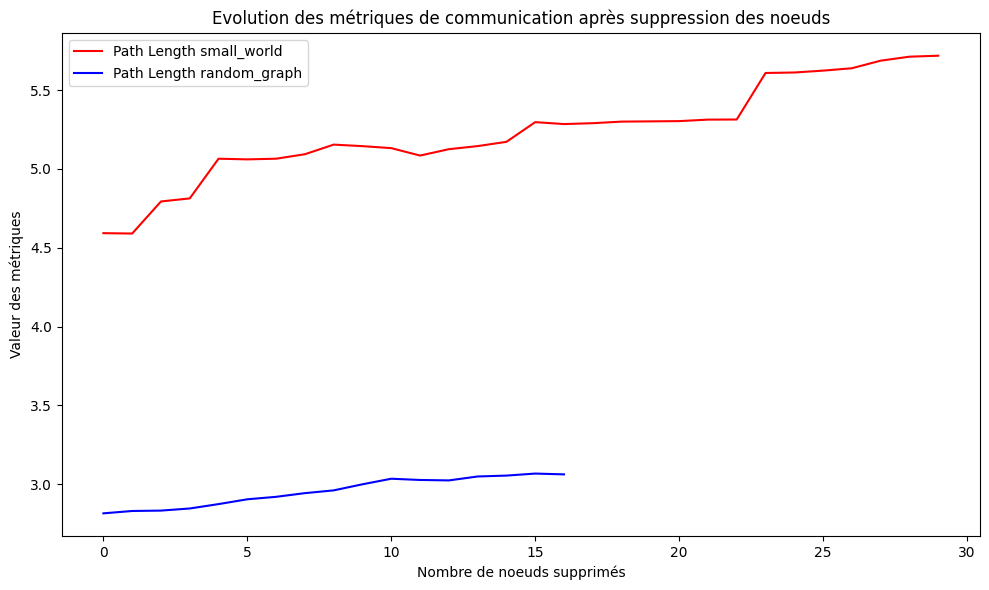

In [17]:
def remove_nodes(graph, num_iterations=30):

    path_length_values = []

    remaining_nodes = list(graph.nodes())
    graph_chunked = graph.copy()

    for _ in range(min(num_iterations, len(remaining_nodes))):

        node_to_remove = random.choice(remaining_nodes)
        remaining_nodes.remove(node_to_remove)
        graph_chunked.remove_node(node_to_remove)
        
        # Vérification si le graphe est toujours connecté pour calculer la path_length
        if nx.is_connected(graph_chunked):
            path_length = nx.average_shortest_path_length(graph_chunked)
        else:
            path_length = float('nan')  # Graphe déconnecté, on attribue NaN à la valeur

        path_length_values.append(path_length)

    return path_length_values

path_length_values_sw = remove_nodes(small_world, num_iterations=30)
path_length_values_rd = remove_nodes(random_graph, num_iterations=30)

fig, ax = plt.subplots(figsize=(10, 6))

# Tracer l'évolution de ces métriques
ax.plot(range(len(path_length_values_sw)), path_length_values_sw, label='Path Length small_world', color='r')
ax.plot(range(len(path_length_values_rd)), path_length_values_rd, label='Path Length random_graph', color='b')
ax.set_title("Evolution des métriques de communication après suppression des noeuds")
ax.set_xlabel("Nombre de noeuds supprimés")
ax.set_ylabel("Valeur des métriques")
ax.legend()
fig.tight_layout()




## Analyse de la production scientifique du CRNL

In [45]:
import pandas as pd
import numpy as np

hal = pd.read_csv('data/HAL_CRNL_20250924.csv')
hal.head(7)


,Equipes,Lien_HAL
0,TRAJECTOIRES,https://hal.science/hal-05144845
1,OFSEP,https://hal.science/hal-05060069
2,ENES,https://hal.science/hal-05077080
3,SPARKLE,https://hal.science/hal-05222897
4,SPARKLE,https://hal.science/hal-04681551
5,PATHPARK;PSYR2,https://hal.science/hal-04951005
6,BIORAN;PSYR2,https://hal.science/hal-05103781


Lorsqu'un article relève d'une collaboration entre plusieurs équipes elles sont séparées par ';'
On peut se créer une liste de tableaux des équipes concernées pour chaque article :

In [46]:
lequipes = [ np.unique(str(t).split(';')) for t in hal['Equipes']]
lequipes[:15]

[array(['TRAJECTOIRES'], dtype='<U12'),
 array(['OFSEP'], dtype='<U5'),
 array(['ENES'], dtype='<U4'),
 array(['SPARKLE'], dtype='<U7'),
 array(['SPARKLE'], dtype='<U7'),
 array(['PATHPARK', 'PSYR2'], dtype='<U8'),
 array(['BIORAN', 'PSYR2'], dtype='<U6'),
 array(['BIORAN'], dtype='<U6'),
 array(['NEUROPAIN'], dtype='<U9'),
 array(["MOUV'HANDI", 'TRAJECTOIRES'], dtype='<U12'),
 array(['ENES'], dtype='<U4'),
 array(['EDUWELL'], dtype='<U7'),
 array(['TRAJECTOIRES'], dtype='<U12'),
 array(['NEUROPOP'], dtype='<U8'),
 array(['NEUROPAIN'], dtype='<U9')]

Puis extraire la liste de toutes les équipes

In [47]:
lesequipes = []
[[lesequipes.append(e) for e in t if e and not e in lesequipes] for t in lequipes]
print(lesequipes)

[np.str_('TRAJECTOIRES'), np.str_('OFSEP'), np.str_('ENES'), np.str_('SPARKLE'), np.str_('PATHPARK'), np.str_('PSYR2'), np.str_('BIORAN'), np.str_('NEUROPAIN'), np.str_("MOUV'HANDI"), np.str_('EDUWELL'), np.str_('NEUROPOP'), np.str_('FORGETTING'), np.str_('GENCYTI'), np.str_('IMPACT'), np.str_('ECC'), np.str_('CAP'), np.str_('TIGER'), np.str_('BRAINGUARD'), np.str_('SLEEP'), np.str_('BIP'), np.str_('GENDEV'), np.str_('iEEG'), np.str_('MAPS'), np.str_('NEF'), np.str_('BI-PHOTON'), np.str_('COPHY'), np.str_('SOCIALHEALTH'), np.str_('NERB'), np.str_('GeneralServices'), np.str_('NDT'), np.str_('SMELL'), np.str_('NEURO-i'), np.str_('Administration'), np.str_('BELIV'), np.str_('Direction'), np.str_('PLANETE'), np.str_('AnimalHousingFacility')]


Ensuite on construit un graphe avec un lien d'autant plus fort entre les équipes qu'il y a de publications communes

In [79]:
G = nx.Graph()
# Pour chaque équipe
for e in lesequipes:
    G.add_node(e)
    # Pour chaque article
    for a in lequipes:
        # si l'équipe est impliquée dans l'article
        if e in a:
            # Faire des liens avec les autres équipes impliquées dans l'article
            liens = [(str(e),str(x)) for x in a if x and not x == e]
            if liens :
                # Pour chaque lien
                for l in liens :
                    # Ajouter 1 au poids du lien entre les 2 équipes
                    w = G.get_edge_data(l[0], l[1]) or {'weight': 0}
                    w = w['weight'] + 1
                    G.add_edge(l[0], l[1], weight = w)
# Pour simplifier le graphe on retire les services techniques et les plateformes
G.remove_node('Administration')
G.remove_node('GeneralServices')
G.remove_node('Direction')
G.remove_node('AnimalHousingFacility')
G.remove_node('BELIV')
G.remove_node('NEURO-i')
G.remove_node('BI-PHOTON')
G.remove_node('iEEG')
G.remove_node('MOUV\'HANDI')
G.remove_node('PLANETE')
G.remove_node('BIP')
G.remove_node('ECC')
G.remove_node('NDT')
G.remove_node('OFSEP')
G.remove_node('GENCYTI')

On peut chercher des détections de communautés mais ça ne fonctionne pas très bien sur ce graphe très connecté

In [110]:
communities = nx.algorithms.community.greedy_modularity_communities(G, weight='weight') # cutoff=3, best_n=6)
print("Nombre de communautés:", len(communities))

Nombre de communautés: 5


Couleurs par communauté pour les nœuds/équipes

In [111]:
dico_nodes = { k:i for i,k in enumerate(G.nodes.keys())}
color_map = [0] * G.number_of_nodes()
for i, comm in enumerate(communities):
    for node in comm:
        color_map[dico_nodes[node]] = i

Épaisseur du trait en fonction du nombre de publications en commun

In [112]:
edge_width = np.log([G.get_edge_data(e[0],e[1])['weight'] for e in G.edges])

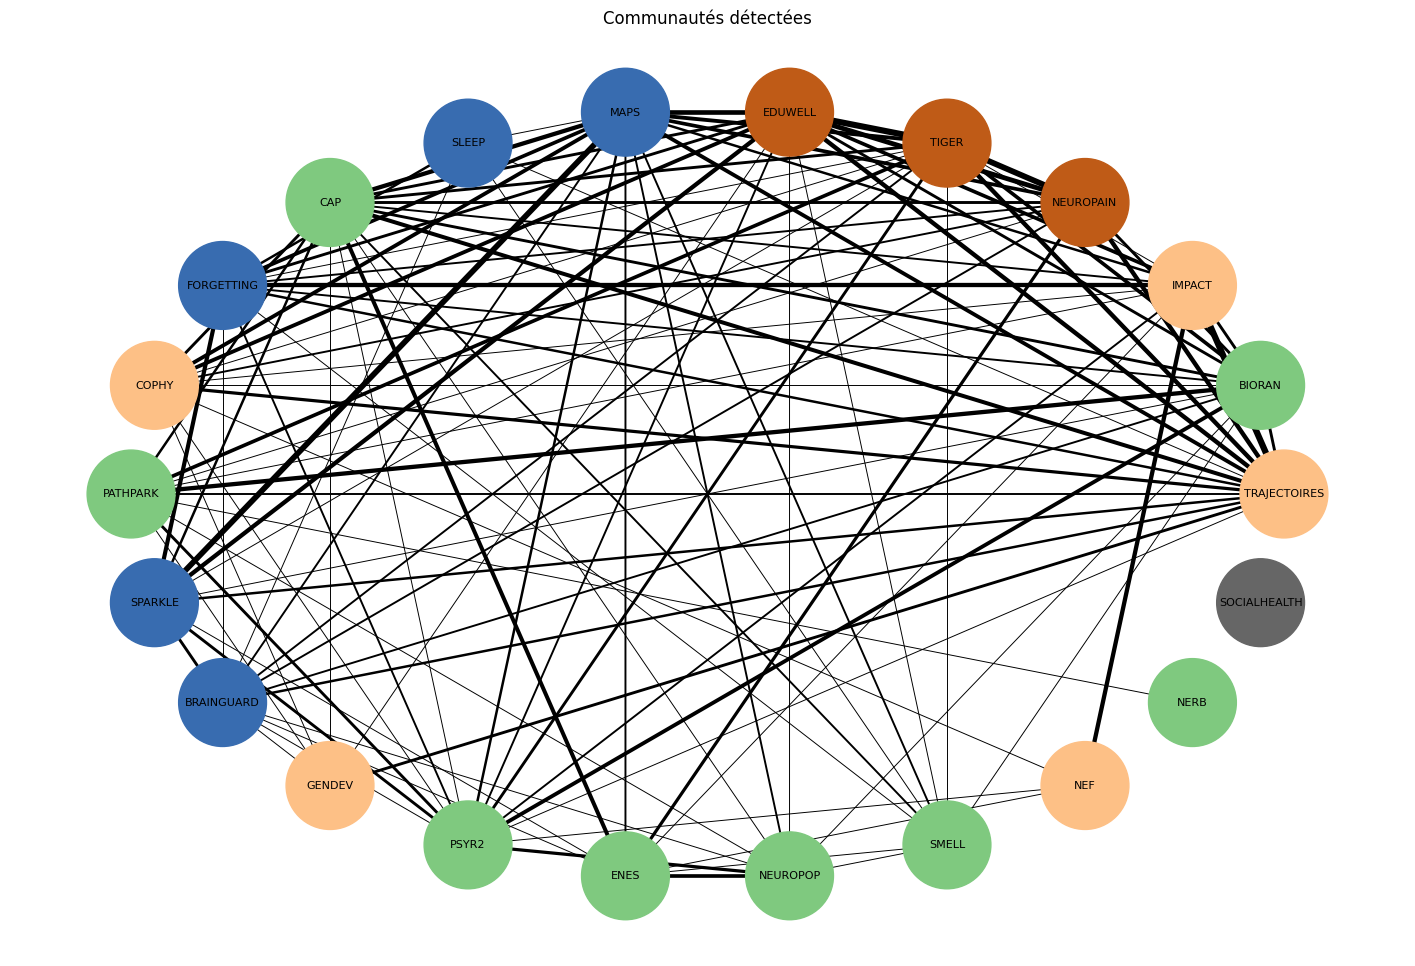

In [113]:
fig, ax = plt.subplots(figsize=(18, 12))
pos0 = nx.drawing.circular_layout(G)
nx.draw(G, node_color=color_map, with_labels=True, cmap=plt.cm.Accent, node_size=4000, 
width=edge_width, pos=pos0, font_size=8)
ax.set_title("Communautés détectées");